# Airport Dataset Exploratory Data Analysis (CO1–CO6)
This notebook is simplified according to your syllabus.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

df=pd.read_csv('airports.csv')
print("Shape:",df.shape)
display(df.head())
df.info()

Shape: (322, 7)


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   IATA_CODE  322 non-null    str    
 1   AIRPORT    322 non-null    str    
 2   CITY       322 non-null    str    
 3   STATE      322 non-null    str    
 4   COUNTRY    322 non-null    str    
 5   LATITUDE   319 non-null    float64
 6   LONGITUDE  319 non-null    float64
dtypes: float64(2), str(5)
memory usage: 33.4 KB


## CO1 - Data Cleaning

In [14]:
print(df.isnull().sum())
print("Duplicates:",df.duplicated().sum())
df=df.drop_duplicates()

IATA_CODE    0
AIRPORT      0
CITY         0
STATE        0
COUNTRY      0
LATITUDE     3
LONGITUDE    3
dtype: int64
Duplicates: 0


## CO2 - Descriptive Statistics

In [15]:
num=df.select_dtypes(include=np.number)
display(num.describe())
print("Median\n",num.median())
print("Mode\n",num.mode().iloc[0])
print("Variance\n",num.var())
print("Standard Deviation\n",num.std())
print("IQR\n",num.quantile(0.75)-num.quantile(0.25))

,LATITUDE,LONGITUDE
count,319.000000,319.000000
mean,38.981244,-98.378964
std,8.616736,21.523492
min,13.483450,-176.646030
25%,33.652040,-110.839385
50%,39.297610,-93.403070
75%,43.154675,-82.722995
max,71.285450,-64.798560


Median
 LATITUDE     39.29761
LONGITUDE   -93.40307
dtype: float64
Mode
 LATITUDE      13.48345
LONGITUDE   -176.64603
Name: 0, dtype: float64
Variance
 LATITUDE      74.248132
LONGITUDE    463.260710
dtype: float64
Standard Deviation
 LATITUDE      8.616736
LONGITUDE    21.523492
dtype: float64
IQR
 LATITUDE      9.502635
LONGITUDE    28.116390
dtype: float64


## CO3 - Probability

Probability airport is in USA: 1.0


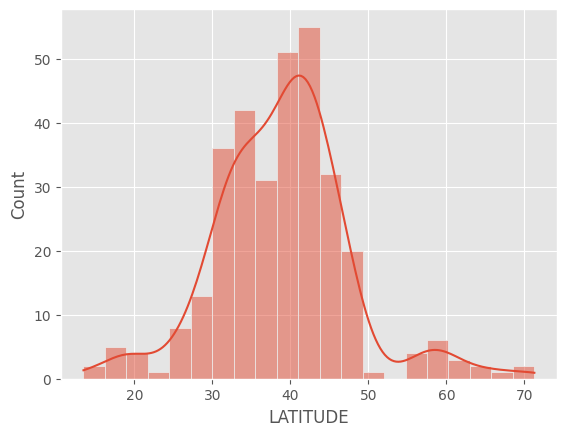

In [16]:
print("Probability airport is in USA:",(df['COUNTRY']=='USA').mean())
sns.histplot(df['LATITUDE'],kde=True)
plt.show()

## CO4 - Hypothesis Testing

In [17]:
print(stats.ttest_1samp(df['LATITUDE'],df['LATITUDE'].mean()))
print(stats.chi2_contingency(pd.crosstab(df['STATE'],df['COUNTRY']))[:2])

TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))
(0.0, 1.0)


## CO5 - Correlation & Regression

,LATITUDE,LONGITUDE
LATITUDE,1.000000,-0.317575
LONGITUDE,-0.317575,1.000000


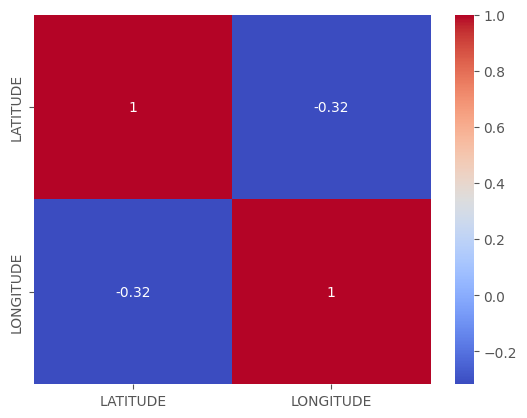

MSE 415.23323864409355
RMSE 20.37727260072097
MAE 15.696992101468897
R2 0.10085402308932334


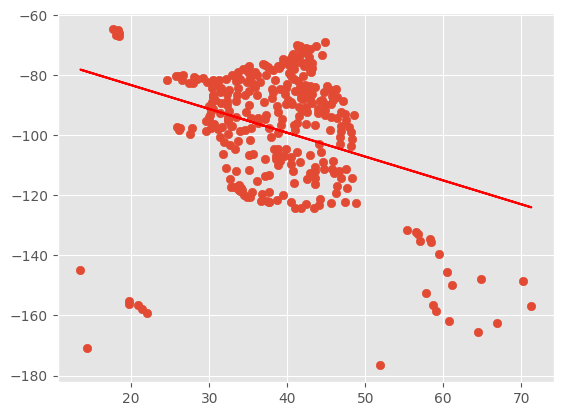

In [18]:
corr=num.corr()
display(corr)
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

df_reg = df.dropna(subset=['LATITUDE', 'LONGITUDE'])
X = df_reg[['LATITUDE']]
y = df_reg['LONGITUDE']
model=LinearRegression().fit(X,y)
pred=model.predict(X)
print("MSE",mean_squared_error(y,pred))
print("RMSE",np.sqrt(mean_squared_error(y,pred)))
print("MAE",mean_absolute_error(y,pred))
print("R2",r2_score(y,pred))
plt.scatter(X,y)
plt.plot(X,pred,color='red')
plt.show()

## CO6 - Visualization & Insights

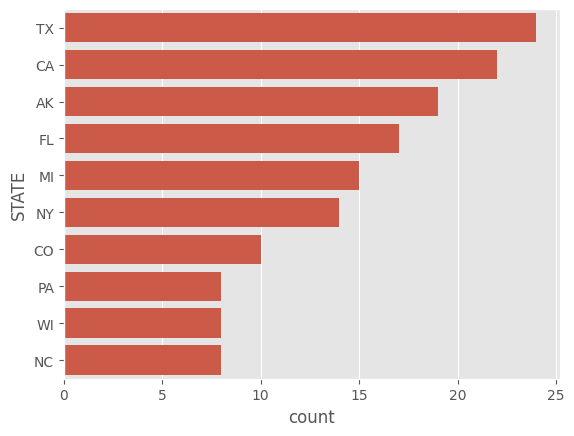

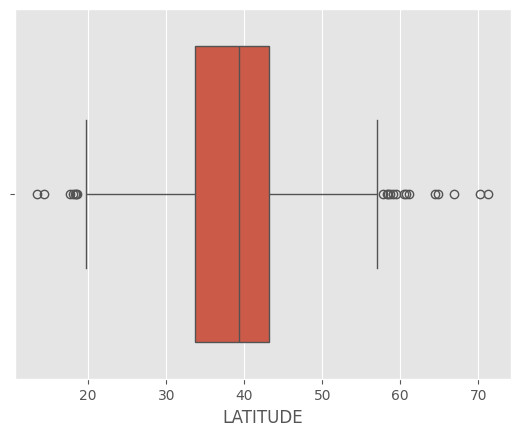

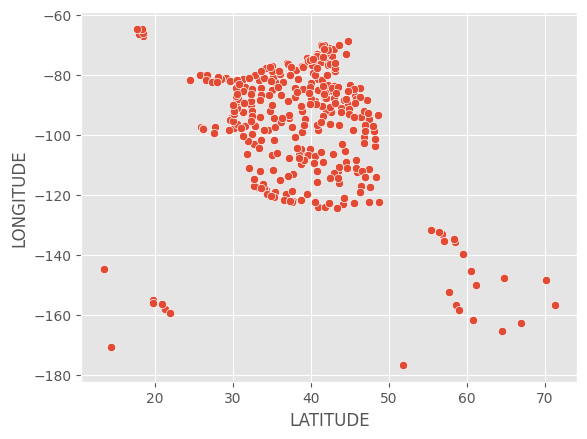

In [19]:
sns.countplot(y=df['STATE'],order=df['STATE'].value_counts().head(10).index)
plt.show()

sns.boxplot(x=df['LATITUDE'])
plt.show()

sns.scatterplot(data=df,x='LATITUDE',y='LONGITUDE')
plt.show()

# Conclusion

- Data cleaned and inspected.
- Measures of central tendency and dispersion calculated.
- Probability example demonstrated.
- t-test and Chi-square included.
- Correlation and Linear Regression performed.
- Visualizations created.

## Future Scope
- Machine Learning
- Dashboard Development
- Predictive Analytics
